# ORACLE APPLS Option 2 - Metric Sensitivity Evaluation

Empirical verification that ORACLE's metrics (FK, ROUGE-L, BERTScore) respond correctly
to controlled perturbations on ORACLE's own PLABA test split.

Decision 15: Upgrades Decision 14 citation-based justification to empirical.

Three perturbation types tested:
- delete_sentence: informativeness criterion (sentence deletion)
- coherent: coherence criterion (sentence reordering)
- simplification: simplification criterion (lexical substitution)

In [1]:
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
from appls_evaluation import run_evaluation

In [2]:
results = run_evaluation()


Processing delete_sentence (Informativeness)...
  Computing FK grade...


  Computing ROUGE-L...


  Computing BERTScore (sample 100)...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  FK:        r=-0.080, p=0.003
  ROUGE-L:   r=-0.982, p=0.000
  BERTScore: r=-0.973, p=0.000

Processing coherent (Coherence)...
  Computing FK grade...


...

  Computing BERTScore (sample 100)...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  FK:        r=-0.184, p=0.000
  ROUGE-L:   r=-0.859, p=0.000
  BERTScore: r=-0.875, p=0.000



Figure saved: /Users/nithinnarla/nithin-research/oracle-rag-pipeline/figures/stage4/appls_metric_sensitivity.png
Figure saved: /Users/nithinnarla/nithin-research/oracle-rag-pipeline/figures/stage4/appls_fk_sensitivity.png

=== SUMMARY ===


           task       criterion   fk_corr  rouge_corr  bert_corr
delete_sentence Informativeness -0.080499   -0.981933  -0.973368
       coherent       Coherence  0.281123   -0.837754  -0.627630
 simplification  Simplification -0.183860   -0.858930  -0.875473


In [3]:
print(results[['task','criterion','fk_corr','rouge_corr','bert_corr']].to_string(index=False))

           task       criterion   fk_corr  rouge_corr  bert_corr
delete_sentence Informativeness -0.080499   -0.981933  -0.973368
       coherent       Coherence  0.281123   -0.837754  -0.627630
 simplification  Simplification -0.183860   -0.858930  -0.875473


## Results Summary

ROUGE-L and BERTScore are strongly sensitive to informativeness, coherence, and simplification perturbations (r=-0.86, -0.88 for simplification specifically).
FK Grade shows weak sensitivity to simplification (r=-0.18) but correctly shows no sensitivity to informativeness or coherence - it measures readability, not information content or order.

Figures saved to figures/stage4/:
- appls_metric_sensitivity.png: ROUGE-L and BERTScore sensitivity curves
- appls_fk_sensitivity.png: FK Grade sensitivity curves across all three perturbation types

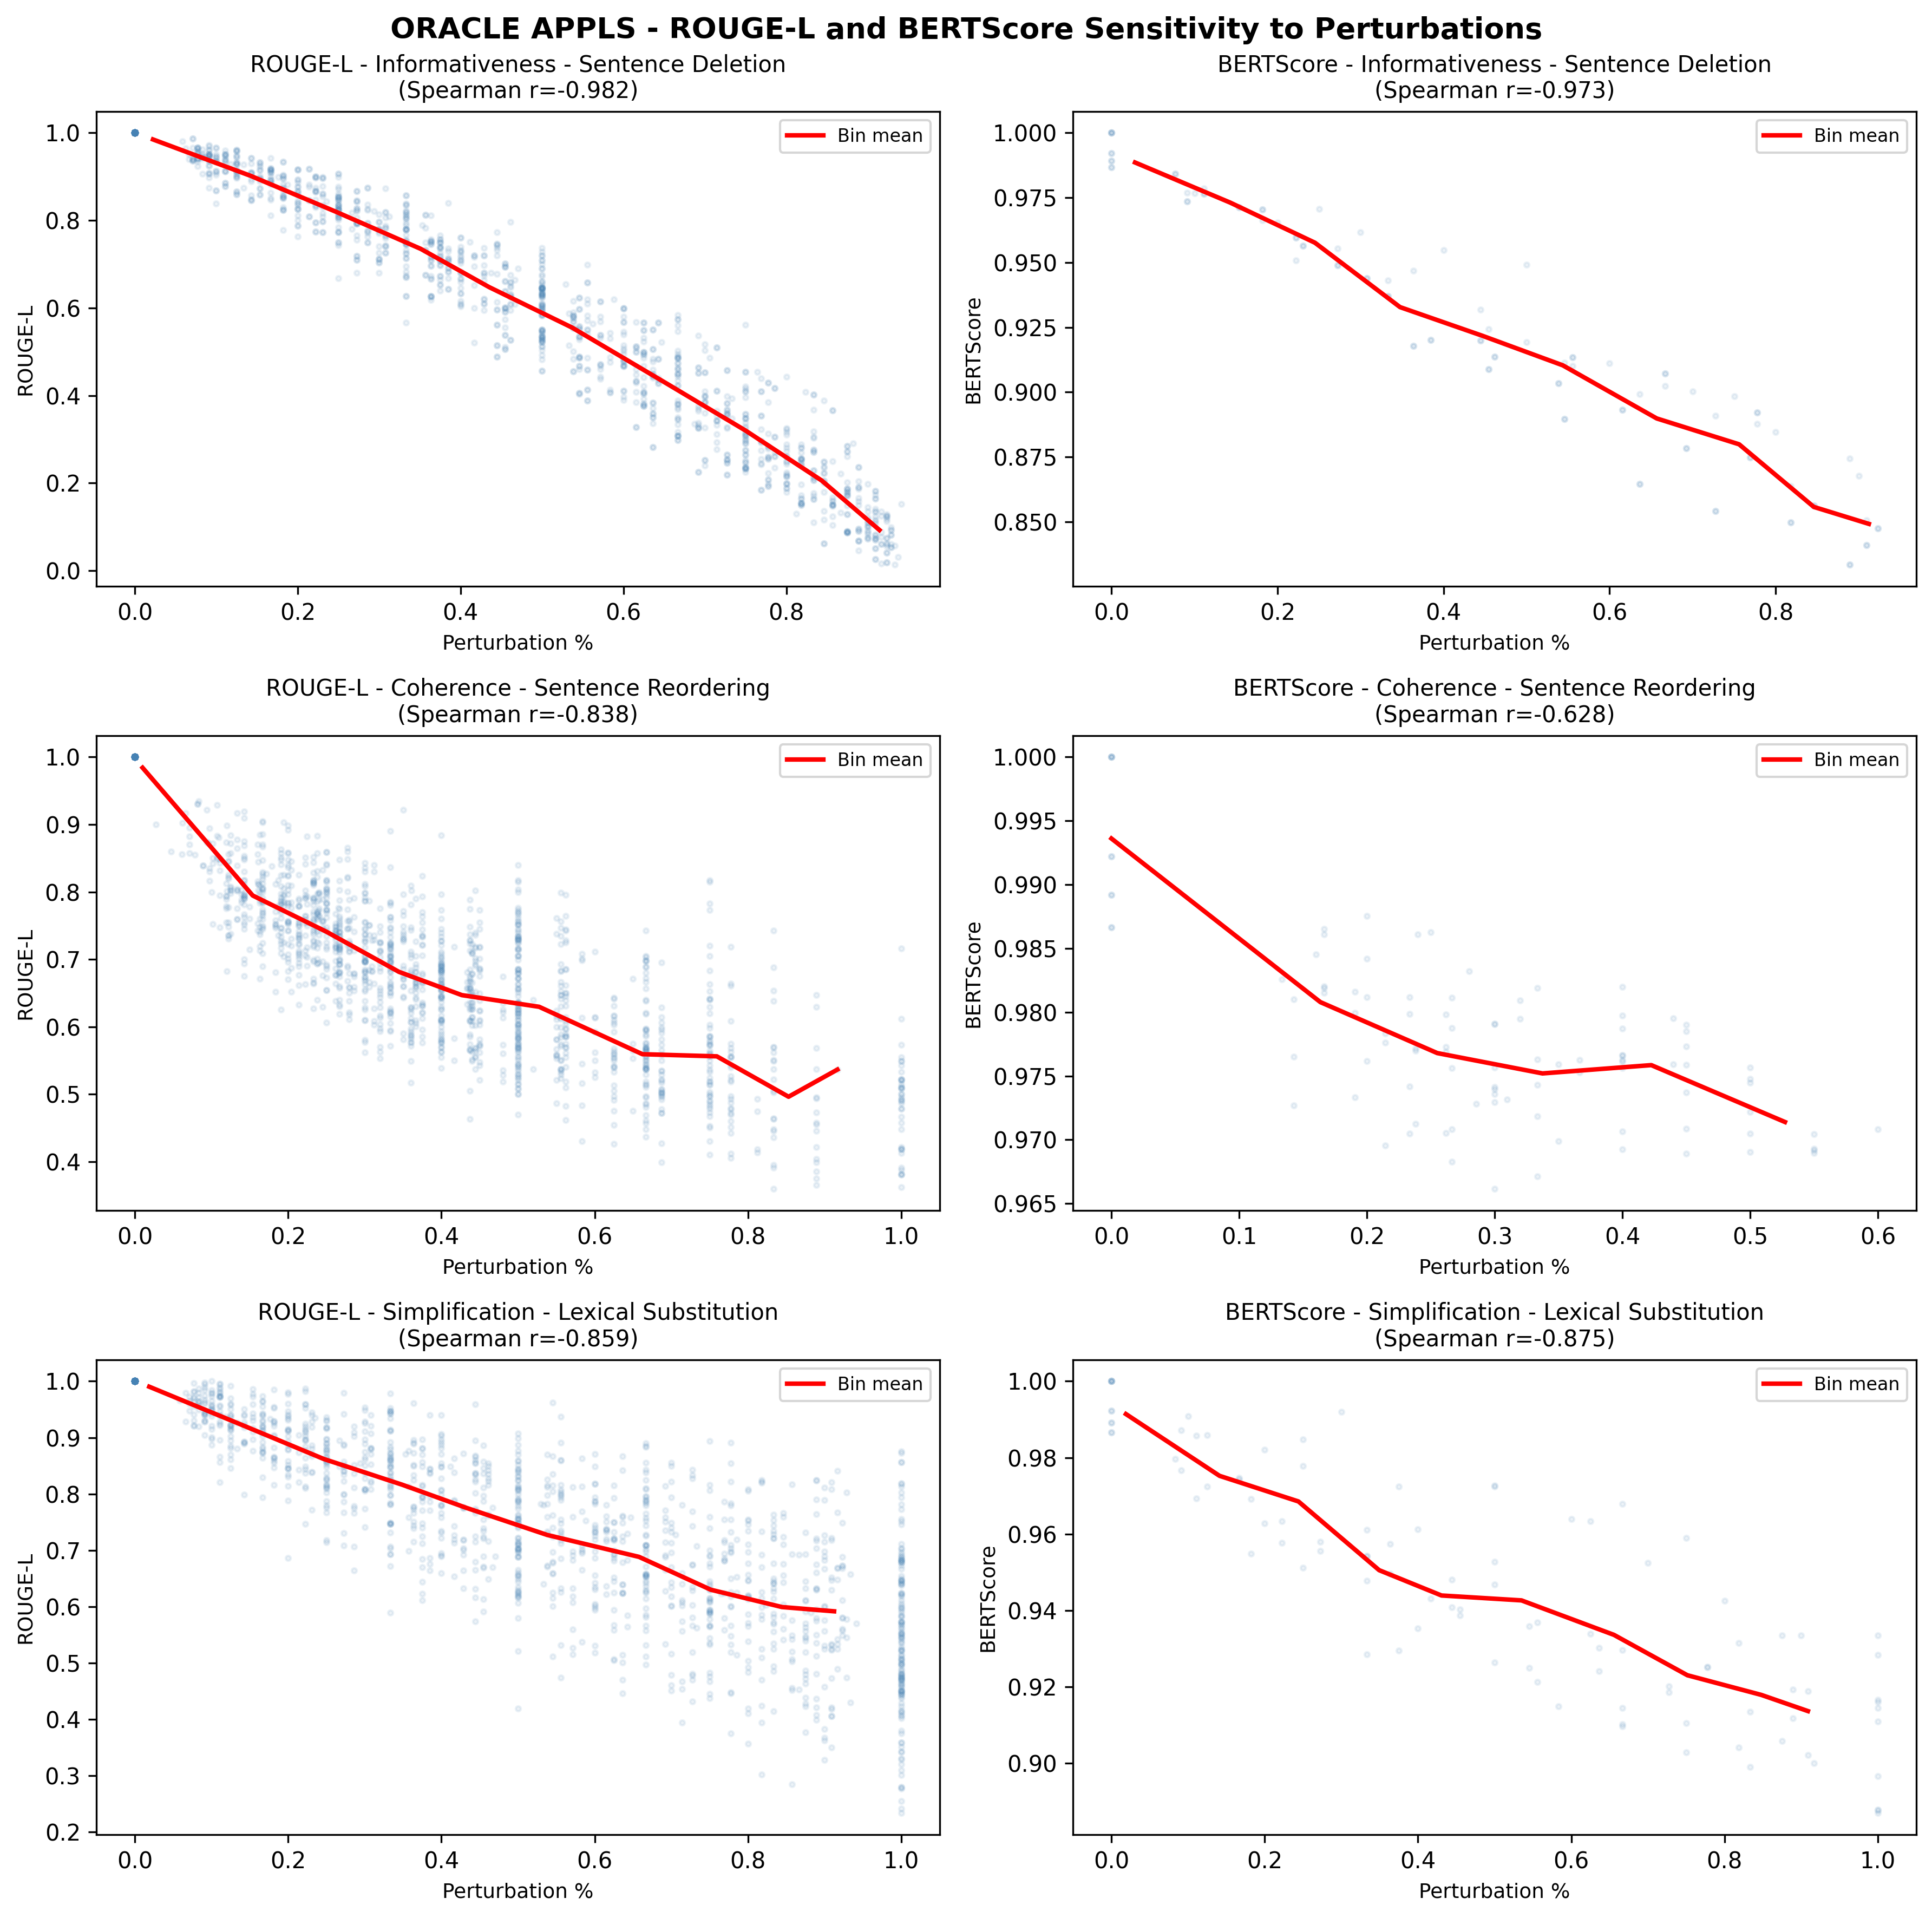

In [4]:
from IPython.display import Image
Image('../figures/stage4/appls_metric_sensitivity.png')

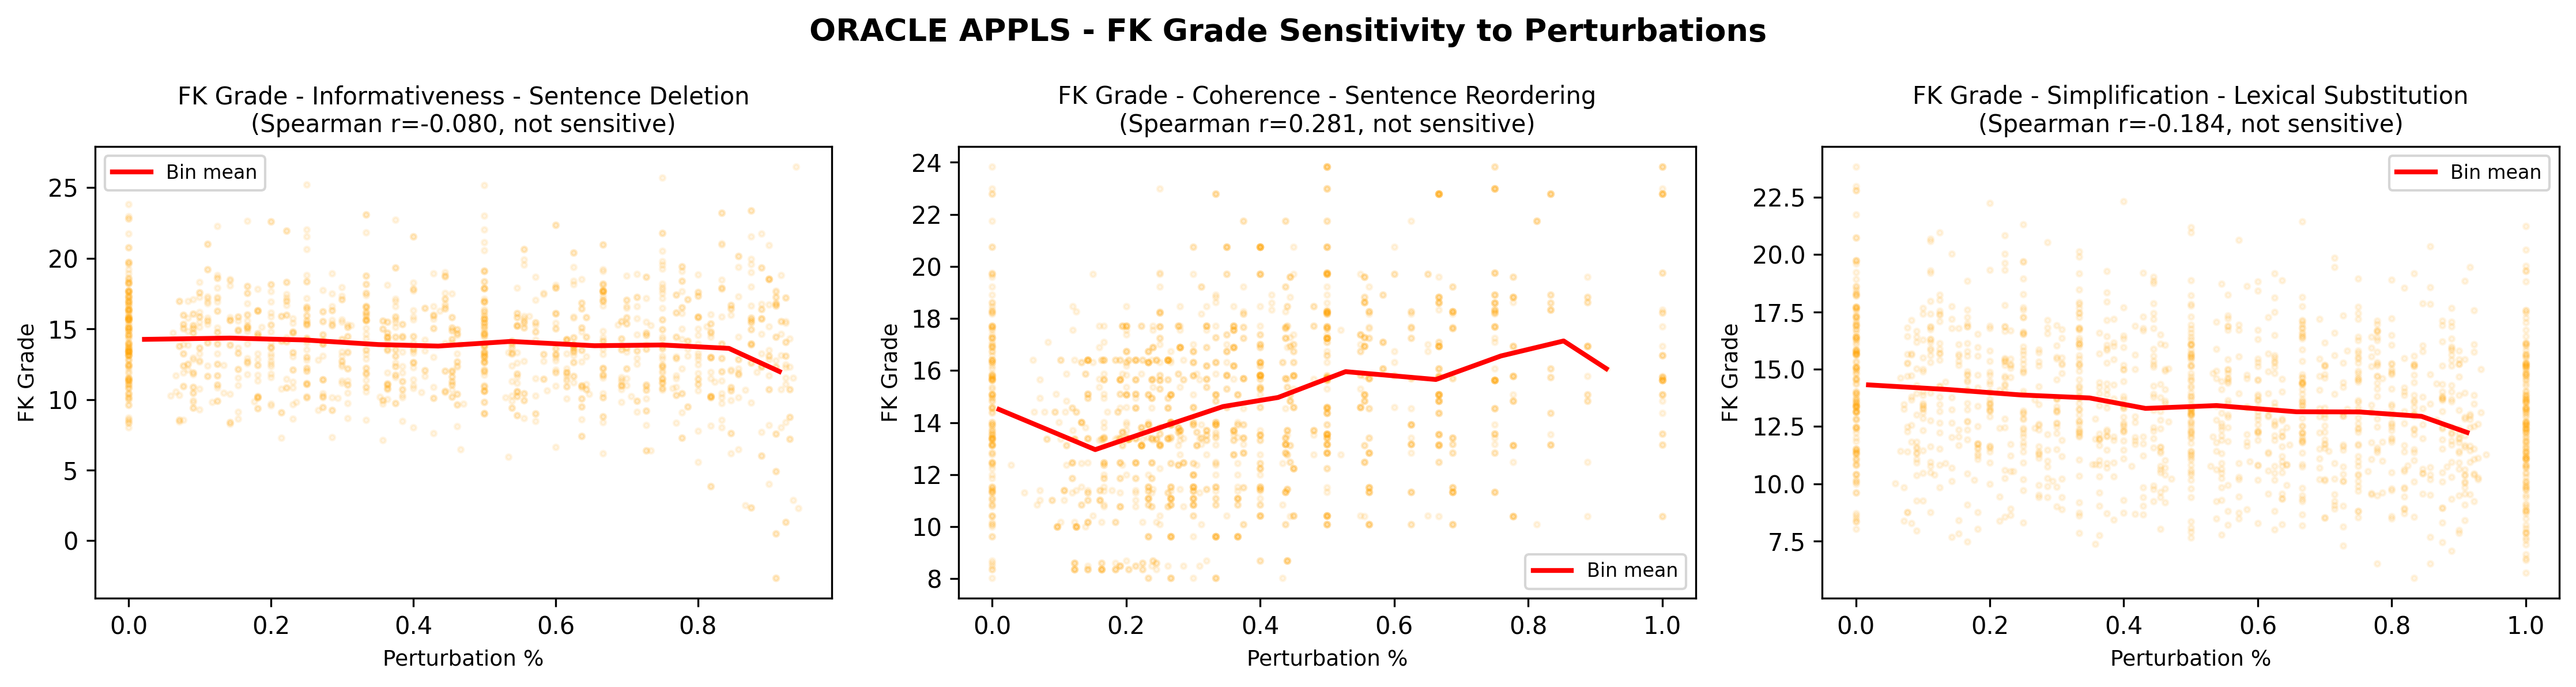

In [5]:
Image('../figures/stage4/appls_fk_sensitivity.png')